# 02 – Data Preparation
Merging two heterogeneous PII datasets into a single unified format: label mapping, WordPiece reconstruction, deduplication, and stratified splitting.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. The challenge: two datasets, different schemas

The two source datasets differ in **tokenization**, **label names**, and **entity granularity**.
We need a single unified format before we can train or evaluate any model.

| Aspect | Kaggle PII Data Detection | ai4privacy PII43k |
|---|---|---|
| Tokenization | Word-level (`"Aaliyah"`, `"Popova,"`) | WordPiece-level (`"dr"`, `"."`, `"mar"`, `"##vin"`) |
| Label column name | `labels` | `Tokens` |
| Person labels | `NAME_STUDENT` | `GIVENNAME`, `SURNAME`, `FULLNAME`, `PREFIX`, `NICKNAME`, … |
| Phone labels | `PHONE_NUM` | `PHONE`, `PHONENUMBER`, `MOBILENUMBER`, `FAXNUMBER`, … |
| Address labels | `STREET_ADDRESS` | `STREET`, `CITY`, `STATE`, `ZIPCODE`, `COUNTRY`, … |
| Trailing whitespace | ✅ Provided | ❌ Not provided |
| Extra entity types | — | `JOBAREA`, `DOB`, `GENDER`, `COMPANYNAME`, … (discarded) |

In [3]:
import ast
import pandas as pd
from IPython.display import display, HTML

# Load raw datasets
kaggle = pd.read_csv('../pii_dataset.csv/pii_dataset.csv', dtype=str)
ai4p   = pd.read_csv('../PII43k.csv', dtype=str, on_bad_lines='skip', engine='python')

print(f'Kaggle:     {len(kaggle):,} rows, {kaggle.shape[1]} columns')
print(f'ai4privacy: {len(ai4p):,} rows, {ai4p.shape[1]} columns')

Kaggle:     4,434 rows, 16 columns
ai4privacy: 42,759 rows, 4 columns


## 2. Step 1 — Unified label mapping

Both datasets use different names for the same PII concepts. We define a single 7-entity schema
and map every source label to it:

**Unified schema:** `PERSON` · `EMAIL` · `PHONE` · `ADDRESS` · `URL` · `ID` · `USERNAME`

In [4]:
from src.data.label_mapping import _KAGGLE, _AI4PRIVACY

# Show the Kaggle mapping (simple 1:1)
print("=== Kaggle label mapping (7 labels → 7 labels) ===")
for src_lbl, unified in sorted(_KAGGLE.items()):
    print(f"  {src_lbl:20s} → {unified}")

print(f"\n=== ai4privacy label mapping ({len(_AI4PRIVACY)} labels → 7 labels + discarded) ===")

# Group ai4privacy labels by their unified target
from collections import defaultdict
grouped = defaultdict(list)
for src_lbl, unified in _AI4PRIVACY.items():
    grouped[unified].append(src_lbl)

for target in ['PERSON', 'EMAIL', 'PHONE', 'ADDRESS', 'URL', 'ID', 'USERNAME', None]:
    name = target if target else 'DISCARDED (→ O)'
    labels = grouped[target]
    print(f"\n  {name}:")
    print(f"    {', '.join(sorted(labels))}")

=== Kaggle label mapping (7 labels → 7 labels) ===
  EMAIL                → EMAIL
  ID_NUM               → ID
  NAME_STUDENT         → PERSON
  PHONE_NUM            → PHONE
  STREET_ADDRESS       → ADDRESS
  URL_PERSONAL         → URL
  USERNAME             → USERNAME

=== ai4privacy label mapping (79 labels → 7 labels + discarded) ===

  PERSON:
    ALIAS, FULLNAME, GIVENNAME, GIVENNAME1, GIVENNAME2, MIDDLENAME, NAME, NICKNAME, PREFIX, SUFFIX, SURNAME, SURNAME1, SURNAME2

  EMAIL:
    EMAIL, EMAILADDRESS

  PHONE:
    FAXNUMBER, MOBILENUMBER, PHONE, PHONENUMBER, PHONENUMBER2, TELEPHONENUM

  ADDRESS:
    BUILDINGNUMBER, CITY, COUNTRY, COUNTY, POSTCODE, SECONDARYADDRESS, STATE, STREET, STREETADDRESS, ZIP, ZIPCODE

  URL:
    DOMAIN, DOMAINNAME, IPADDRESS, IPV4, IPV6, URL, WEBSITE

  ID:
    ACCOUNTNUMBER, CREDITCARDNUMBER, DRIVERSLICENSE, EMPLOYEEID, IBAN, IDCARD, MEDICALRECORDNUMBER, NIN, PASSPORT, SOCIALINSURANCE, SSN, TAXID, US_ITIN, US_PASSPORT, US_SSN, VEHICLEREGISTRATIONNUMBER

 

### Before vs. after mapping — concrete example

Let's pick a record from each dataset and show the labels before and after unification.

In [5]:
from src.data.label_mapping import map_labels

# Kaggle example
row_k = kaggle.iloc[0]
tokens_k = ast.literal_eval(row_k['tokens'])
labels_k = ast.literal_eval(row_k['labels'])
unified_k = map_labels(labels_k, 'kaggle')

print("=== Kaggle record 0 — PII tokens ===")
print(f"{'Token':<25s} {'Original label':<25s} {'Unified label'}")
print("-" * 75)
for t, orig, uni in zip(tokens_k, labels_k, unified_k):
    if orig != 'O':
        print(f"{t:<25s} {orig:<25s} {uni}")

print()

# ai4privacy example — find one with multiple entity types
for idx, row_a in ai4p.iterrows():
    lbls = ast.literal_eval(row_a['Tokens'])
    types = set(l.split('-',1)[1] for l in lbls if l != 'O')
    if len(types) >= 3:
        toks_a = ast.literal_eval(row_a['Tokenised Filled Template'])
        unified_a = map_labels(lbls, 'ai4privacy')
        print(f"=== ai4privacy record {idx} — PII tokens ===")
        print(f"{'Token':<25s} {'Original label':<25s} {'Unified label'}")
        print("-" * 75)
        for t, orig, uni in zip(toks_a, lbls, unified_a):
            if orig != 'O':
                print(f"{t:<25s} {orig:<25s} {uni}")
        break

=== Kaggle record 0 — PII tokens ===
Token                     Original label            Unified label
---------------------------------------------------------------------------
Aaliyah                   B-NAME_STUDENT            B-PERSON
Popova,                   I-NAME_STUDENT            I-PERSON
(95)                      B-PHONE_NUM               B-PHONE
94215-7906                I-PHONE_NUM               I-PHONE
aaliyah.popova4783@aol.edu. B-EMAIL                   B-EMAIL
97                        B-STREET_ADDRESS          B-ADDRESS
Lincoln                   I-STREET_ADDRESS          I-ADDRESS
Street.                   I-STREET_ADDRESS          I-ADDRESS

=== ai4privacy record 6 — PII tokens ===
Token                     Original label            Unified label
---------------------------------------------------------------------------
heller                    B-NAME                    B-PERSON
-                         I-NAME                    I-PERSON
di                       

## 3. Step 2 — WordPiece reconstruction (ai4privacy only)

The ai4privacy dataset uses **WordPiece tokenization** where long words are split into sub-tokens prefixed with `##`.
For example, `"Marvin"` might become `["mar", "##vin"]`. We must merge these back into whole words
before combining with the Kaggle word-level tokens.

The first sub-token keeps its BIO label; `##` continuations are appended to the previous word.

In [6]:
from src.data.loaders import _reconstruct_from_wordpiece

# Row 1 has two clear multi-piece merges inside PII spans
row = ai4p.iloc[1]
wp_tokens = ast.literal_eval(row['Tokenised Filled Template'])
wp_labels = ast.literal_eval(row['Tokens'])

words, word_labels = _reconstruct_from_wordpiece(wp_tokens, wp_labels)

print("=== Before reconstruction (WordPiece sub-tokens) ===")
print(f"  Tokens ({len(wp_tokens)}): {wp_tokens}")
print()

# Show PII tokens with ## markers highlighted
print("  PII sub-tokens:")
for t, l in zip(wp_tokens, wp_labels):
    if l != 'O':
        marker = '  ← continuation piece' if t.startswith('##') else ''
        print(f"    {t:15s} {l}{marker}")

print(f"\n=== After reconstruction (word-level) ===")
print(f"  Tokens ({len(words)}): {words}")
print()
print("  PII words (after merge):")
for w, l in zip(words, word_labels):
    if l != 'O':
        print(f"    {w:15s} {l}")

print(f"\n=== What happened ===")
print(f"  ['sc', '##hul', '##ist']    →  'schulist'     (3 sub-tokens → 1 word)")
print(f"  ['roma', '##gue', '##ra']   →  'romaguera'    (3 sub-tokens → 1 word)")
print(f"  {len(wp_tokens)} sub-tokens → {len(words)} words total")

=== Before reconstruction (WordPiece sub-tokens) ===
  Tokens (29): ['could', 'you', 'draft', 'a', 'letter', 'for', 'dietrich', ',', 'sc', '##hul', '##ist', 'and', 'roma', '##gue', '##ra', 'to', 'send', 'to', 'their', 'insurance', 'company', 'regarding', 'a', 'claim', 'dispute', 'under', 'washington', 'law', '?']

  PII sub-tokens:
    dietrich        B-NAME
    ,               I-NAME
    sc              I-NAME
    ##hul           I-NAME  ← continuation piece
    ##ist           I-NAME  ← continuation piece
    and             I-NAME
    roma            I-NAME
    ##gue           I-NAME  ← continuation piece
    ##ra            I-NAME  ← continuation piece
    washington      B-STATE

=== After reconstruction (word-level) ===
  Tokens (25): ['could', 'you', 'draft', 'a', 'letter', 'for', 'dietrich', ',', 'schulist', 'and', 'romaguera', 'to', 'send', 'to', 'their', 'insurance', 'company', 'regarding', 'a', 'claim', 'dispute', 'under', 'washington', 'law', '?']

  PII words (after merge)

## 4. Step 3 — Merge into unified record format

After label mapping and WordPiece reconstruction, every record from both datasets has the same structure:

```python
{
    "tokens": ["My", "name", "is", "Aaliyah", "Popova,", ...],
    "labels": ["O",  "O",    "O",  "B-PERSON","I-PERSON", ...],
    "source": "kaggle" | "ai4privacy",
    "trailing_whitespace": [True, True, ...]  # Kaggle only
}
```

We concatenate all records into a single list.

In [7]:
from src.data.loaders import load_kaggle_dataset, load_ai4privacy_dataset

kaggle_records = load_kaggle_dataset('../pii_dataset.csv/pii_dataset.csv')
ai4p_records   = load_ai4privacy_dataset('../PII43k.csv')
all_records    = kaggle_records + ai4p_records

print(f"Kaggle records:     {len(kaggle_records):,}")
print(f"ai4privacy records: {len(ai4p_records):,}")
print(f"Combined total:     {len(all_records):,}")
print(f"\nRecord format keys: {list(all_records[0].keys())}")
print(f"  Kaggle sample:     tokens={all_records[0]['tokens'][:5]}, labels={all_records[0]['labels'][:5]}")
print(f"  ai4privacy sample: tokens={ai4p_records[0]['tokens'][:5]}, labels={ai4p_records[0]['labels'][:5]}")

[label_mapping] Unknown entity 'FIRSTNAME' in source 'ai4privacy' → mapped to O
[label_mapping] Unknown entity 'LASTNAME' in source 'ai4privacy' → mapped to O
[label_mapping] Unknown entity 'PASSWORD' in source 'ai4privacy' → mapped to O
[label_mapping] Unknown entity 'NUMBER' in source 'ai4privacy' → mapped to O
[label_mapping] Unknown entity 'IP' in source 'ai4privacy' → mapped to O
[label_mapping] Unknown entity 'JOBTYPE' in source 'ai4privacy' → mapped to O
[label_mapping] Unknown entity 'MAC' in source 'ai4privacy' → mapped to O
[label_mapping] Unknown entity 'MASKEDNUMBER' in source 'ai4privacy' → mapped to O
[label_mapping] Unknown entity 'USERAGENT' in source 'ai4privacy' → mapped to O
[label_mapping] Unknown entity 'BIC' in source 'ai4privacy' → mapped to O
[label_mapping] Unknown entity 'NEARBYGPSCOORDINATE' in source 'ai4privacy' → mapped to O
[label_mapping] Unknown entity 'PIN' in source 'ai4privacy' → mapped to O
[label_mapping] Unknown entity 'CURRENCYSYMBOL' in source '

## 5. Step 4 — Stratified split (80/10/10)

We split by **PII presence** (records with at least one PII token vs. all-O) to maintain balanced PII density across train/val/test.

train=37,661  val=4,707  test=4,710


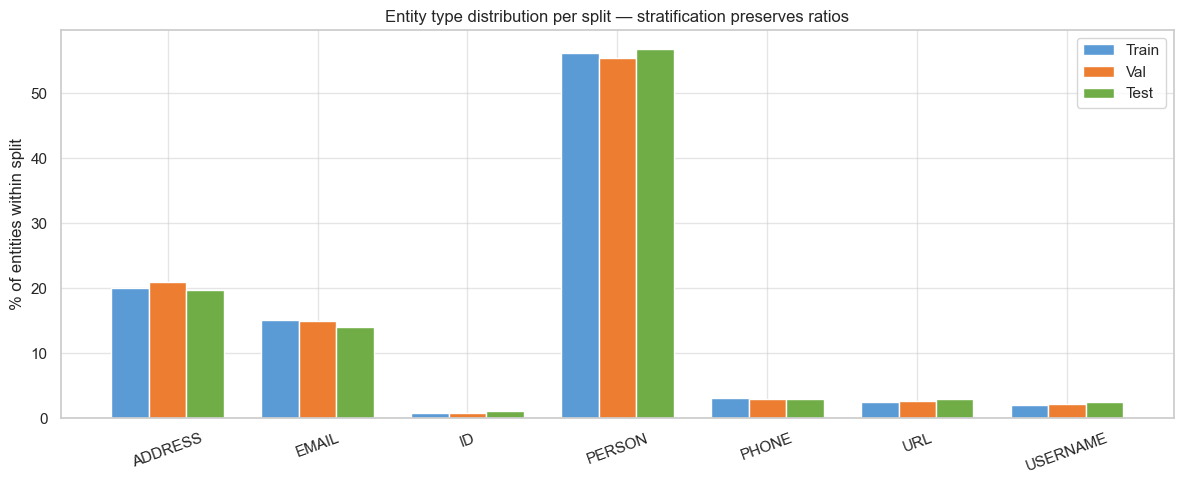

         Train % Val % Test %
ADDRESS     20.0  21.0   19.7
EMAIL       15.2  15.0   14.0
ID           0.8   0.8    1.1
PERSON      56.2  55.4   56.8
PHONE        3.2   2.9    2.9
URL          2.5   2.7    2.9
USERNAME     2.1   2.2    2.5


In [8]:
from pathlib import Path
from src.utils.io import load_jsonl
import numpy as np

processed = Path('../data/processed')

if not (processed / 'train.jsonl').exists():
    print('Running prepare_data.py ...')
    import subprocess
    subprocess.run(['python', '../prepare_data.py'], check=True)

train = load_jsonl(processed / 'train.jsonl')
val   = load_jsonl(processed / 'val.jsonl')
test  = load_jsonl(processed / 'test.jsonl')
print(f'train={len(train):,}  val={len(val):,}  test={len(test):,}')

# Count entity occurrences per split
from collections import Counter

def count_entities(records):
    cnt = Counter()
    for rec in records:
        for lbl in rec['labels']:
            if lbl.startswith('B-'):
                cnt[lbl[2:]] += 1
    return cnt

train_cnt = count_entities(train)
val_cnt   = count_entities(val)
test_cnt  = count_entities(test)

entities = sorted(set(train_cnt) | set(val_cnt) | set(test_cnt))

# Plot side-by-side bars (normalized to % within each split)
x = np.arange(len(entities))
width = 0.25

train_total = sum(train_cnt.values())
val_total   = sum(val_cnt.values())
test_total  = sum(test_cnt.values())

train_pct = [train_cnt[e] / train_total * 100 for e in entities]
val_pct   = [val_cnt[e] / val_total * 100 for e in entities]
test_pct  = [test_cnt[e] / test_total * 100 for e in entities]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, train_pct, width, label=f'Train', color='#5b9bd5')
ax.bar(x,         val_pct,   width, label=f'Val',   color='#ed7d31')
ax.bar(x + width, test_pct,  width, label=f'Test',  color='#70ad47')

ax.set_ylabel('% of entities within split')
ax.set_title('Entity type distribution per split — stratification preserves ratios')
ax.set_xticks(x)
ax.set_xticklabels(entities, rotation=20)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/results/unified_label_dist.png', dpi=150)
plt.show()

# Print exact percentages
split_df = pd.DataFrame({
    'Train %': [f'{v:.1f}' for v in train_pct],
    'Val %':   [f'{v:.1f}' for v in val_pct],
    'Test %':  [f'{v:.1f}' for v in test_pct],
}, index=entities)
print(split_df.to_string())

## 6. Split statistics — source balance

In [9]:
import pandas as pd

def split_stats(records, name):
    n_pii = sum(1 for r in records if any(l != 'O' for l in r['labels']))
    kaggle = sum(1 for r in records if r.get('source') == 'kaggle')
    ai4p   = sum(1 for r in records if r.get('source') == 'ai4privacy')
    return {'split': name, 'total': len(records), 'has_pii': n_pii,
            'pii_%': f'{n_pii/len(records)*100:.1f}', 'kaggle': kaggle, 'ai4privacy': ai4p}

stats = pd.DataFrame([split_stats(train,'train'), split_stats(val,'val'), split_stats(test,'test')])
stats.set_index('split', inplace=True)
print(stats.to_string())

       total  has_pii pii_%  kaggle  ai4privacy
split                                          
train  37661    34841  92.5    3584       34077
val     4707     4355  92.5     441        4266
test    4710     4356  92.5     409        4301


## 7. Sample unified records

In [10]:
import random
rng = random.Random(42)
pii_samples = [r for r in test if any(l != 'O' for l in r['labels'])]

for rec in rng.sample(pii_samples, 3):
    toks, lbls = rec['tokens'], rec['labels']
    pii = [(t, l) for t, l in zip(toks, lbls) if l != 'O']
    src = rec.get('source', '?')
    print(f'[{src}]  ...{" ".join(toks[:15])}...')
    print(f'  PII: {pii[:6]}')
    print()

[ai4privacy]  ...can you help me create a list of coping strategies for simonis - mueller to...
  PII: [('simonis', 'B-PERSON'), ('-', 'I-PERSON'), ('mueller', 'I-PERSON')]

[kaggle]  ...In the realm of design, Ashok Novikov stands as a beacon of creativity and innovation....
  PII: [('Ashok', 'B-PERSON'), ('Novikov', 'I-PERSON'), ('Ashok', 'B-PERSON'), ("Ashok's", 'B-PERSON'), ('Ashok', 'B-PERSON'), ('Ashok', 'B-PERSON')]

[ai4privacy]  ...draft a pitch deck for crona inc to present their startup idea to potential investors...
  PII: [('crona', 'B-PERSON'), ('inc', 'I-PERSON')]

